In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
df=pd.read_csv('house_price_dataset.csv')
df

,area,bedrooms,bathrooms,stories,parking,age,distance_city,location_score,furnished,price
0,3419,1,1,3,1,8,4.5,4,0,119.0
1,930,1,1,2,1,17,12.8,8,0,61.3
2,3032,4,4,4,2,1,15.7,5,1,131.1
3,1436,2,2,1,0,13,3.7,10,1,97.3
4,977,4,3,4,0,18,7.3,9,1,89.5
...,...,...,...,...,...,...,...,...,...,...
95,1885,3,4,1,2,22,17.5,7,1,93.0
96,2798,5,4,1,1,21,14.3,6,0,116.9
97,2577,1,1,4,1,23,7.4,4,0,83.9
98,1029,3,3,3,3,5,6.4,7,0,80.8


In [3]:
df.shape

(100, 10)

In [4]:
df.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'age',
       'distance_city', 'location_score', 'furnished', 'price'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area            100 non-null    int64  
 1   bedrooms        100 non-null    int64  
 2   bathrooms       100 non-null    int64  
 3   stories         100 non-null    int64  
 4   parking         100 non-null    int64  
 5   age             100 non-null    int64  
 6   distance_city   100 non-null    float64
 7   location_score  100 non-null    int64  
 8   furnished       100 non-null    int64  
 9   price           100 non-null    float64
dtypes: float64(2), int64(8)
memory usage: 7.9 KB


In [6]:
df.isnull().sum()

area              0
bedrooms          0
bathrooms         0
stories           0
parking           0
age               0
distance_city     0
location_score    0
furnished         0
price             0
dtype: int64

In [7]:
df.corr()

,area,bedrooms,bathrooms,stories,parking,age,distance_city,location_score,furnished,price
area,1.000000,0.068013,0.131468,-0.022267,-0.092974,-0.007828,0.035115,-0.099391,0.002525,0.802726
bedrooms,0.068013,1.000000,0.872833,0.034357,0.089622,-0.031281,-0.034633,0.072534,-0.087327,0.415098
bathrooms,0.131468,0.872833,1.000000,0.068073,0.044153,-0.076913,-0.019397,0.129800,-0.086672,0.488961
stories,-0.022267,0.034357,0.068073,1.000000,-0.020985,-0.159747,0.048746,0.071670,0.140741,0.135983
parking,-0.092974,0.089622,0.044153,-0.020985,1.000000,-0.035964,0.059706,0.042720,0.114761,0.045573
age,-0.007828,-0.031281,-0.076913,-0.159747,-0.035964,1.000000,0.016381,0.027295,-0.065602,-0.176598
distance_city,0.035115,-0.034633,-0.019397,0.048746,0.059706,0.016381,1.000000,0.081746,0.162860,-0.092144
location_score,-0.099391,0.072534,0.129800,0.071670,0.042720,0.027295,0.081746,1.000000,-0.044047,0.277600
furnished,0.002525,-0.087327,-0.086672,0.140741,0.114761,-0.065602,0.162860,-0.044047,1.000000,0.075505
price,0.802726,0.415098,0.488961,0.135983,0.045573,-0.176598,-0.092144,0.277600,0.075505,1.000000


<Axes: >

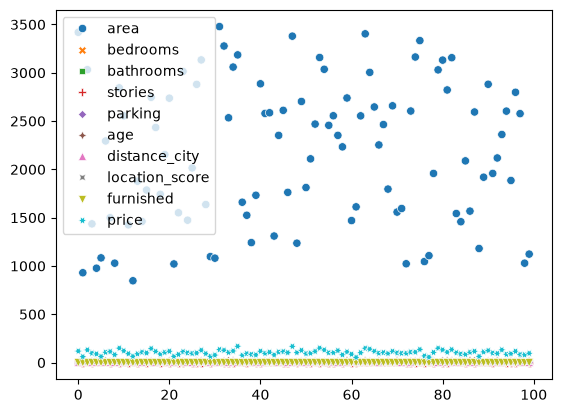

In [8]:
sns.scatterplot(data=df)

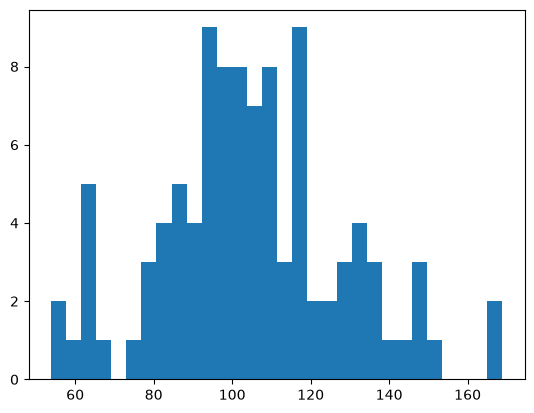

In [28]:
plt.hist(df["price"],bins=30)
plt.show()

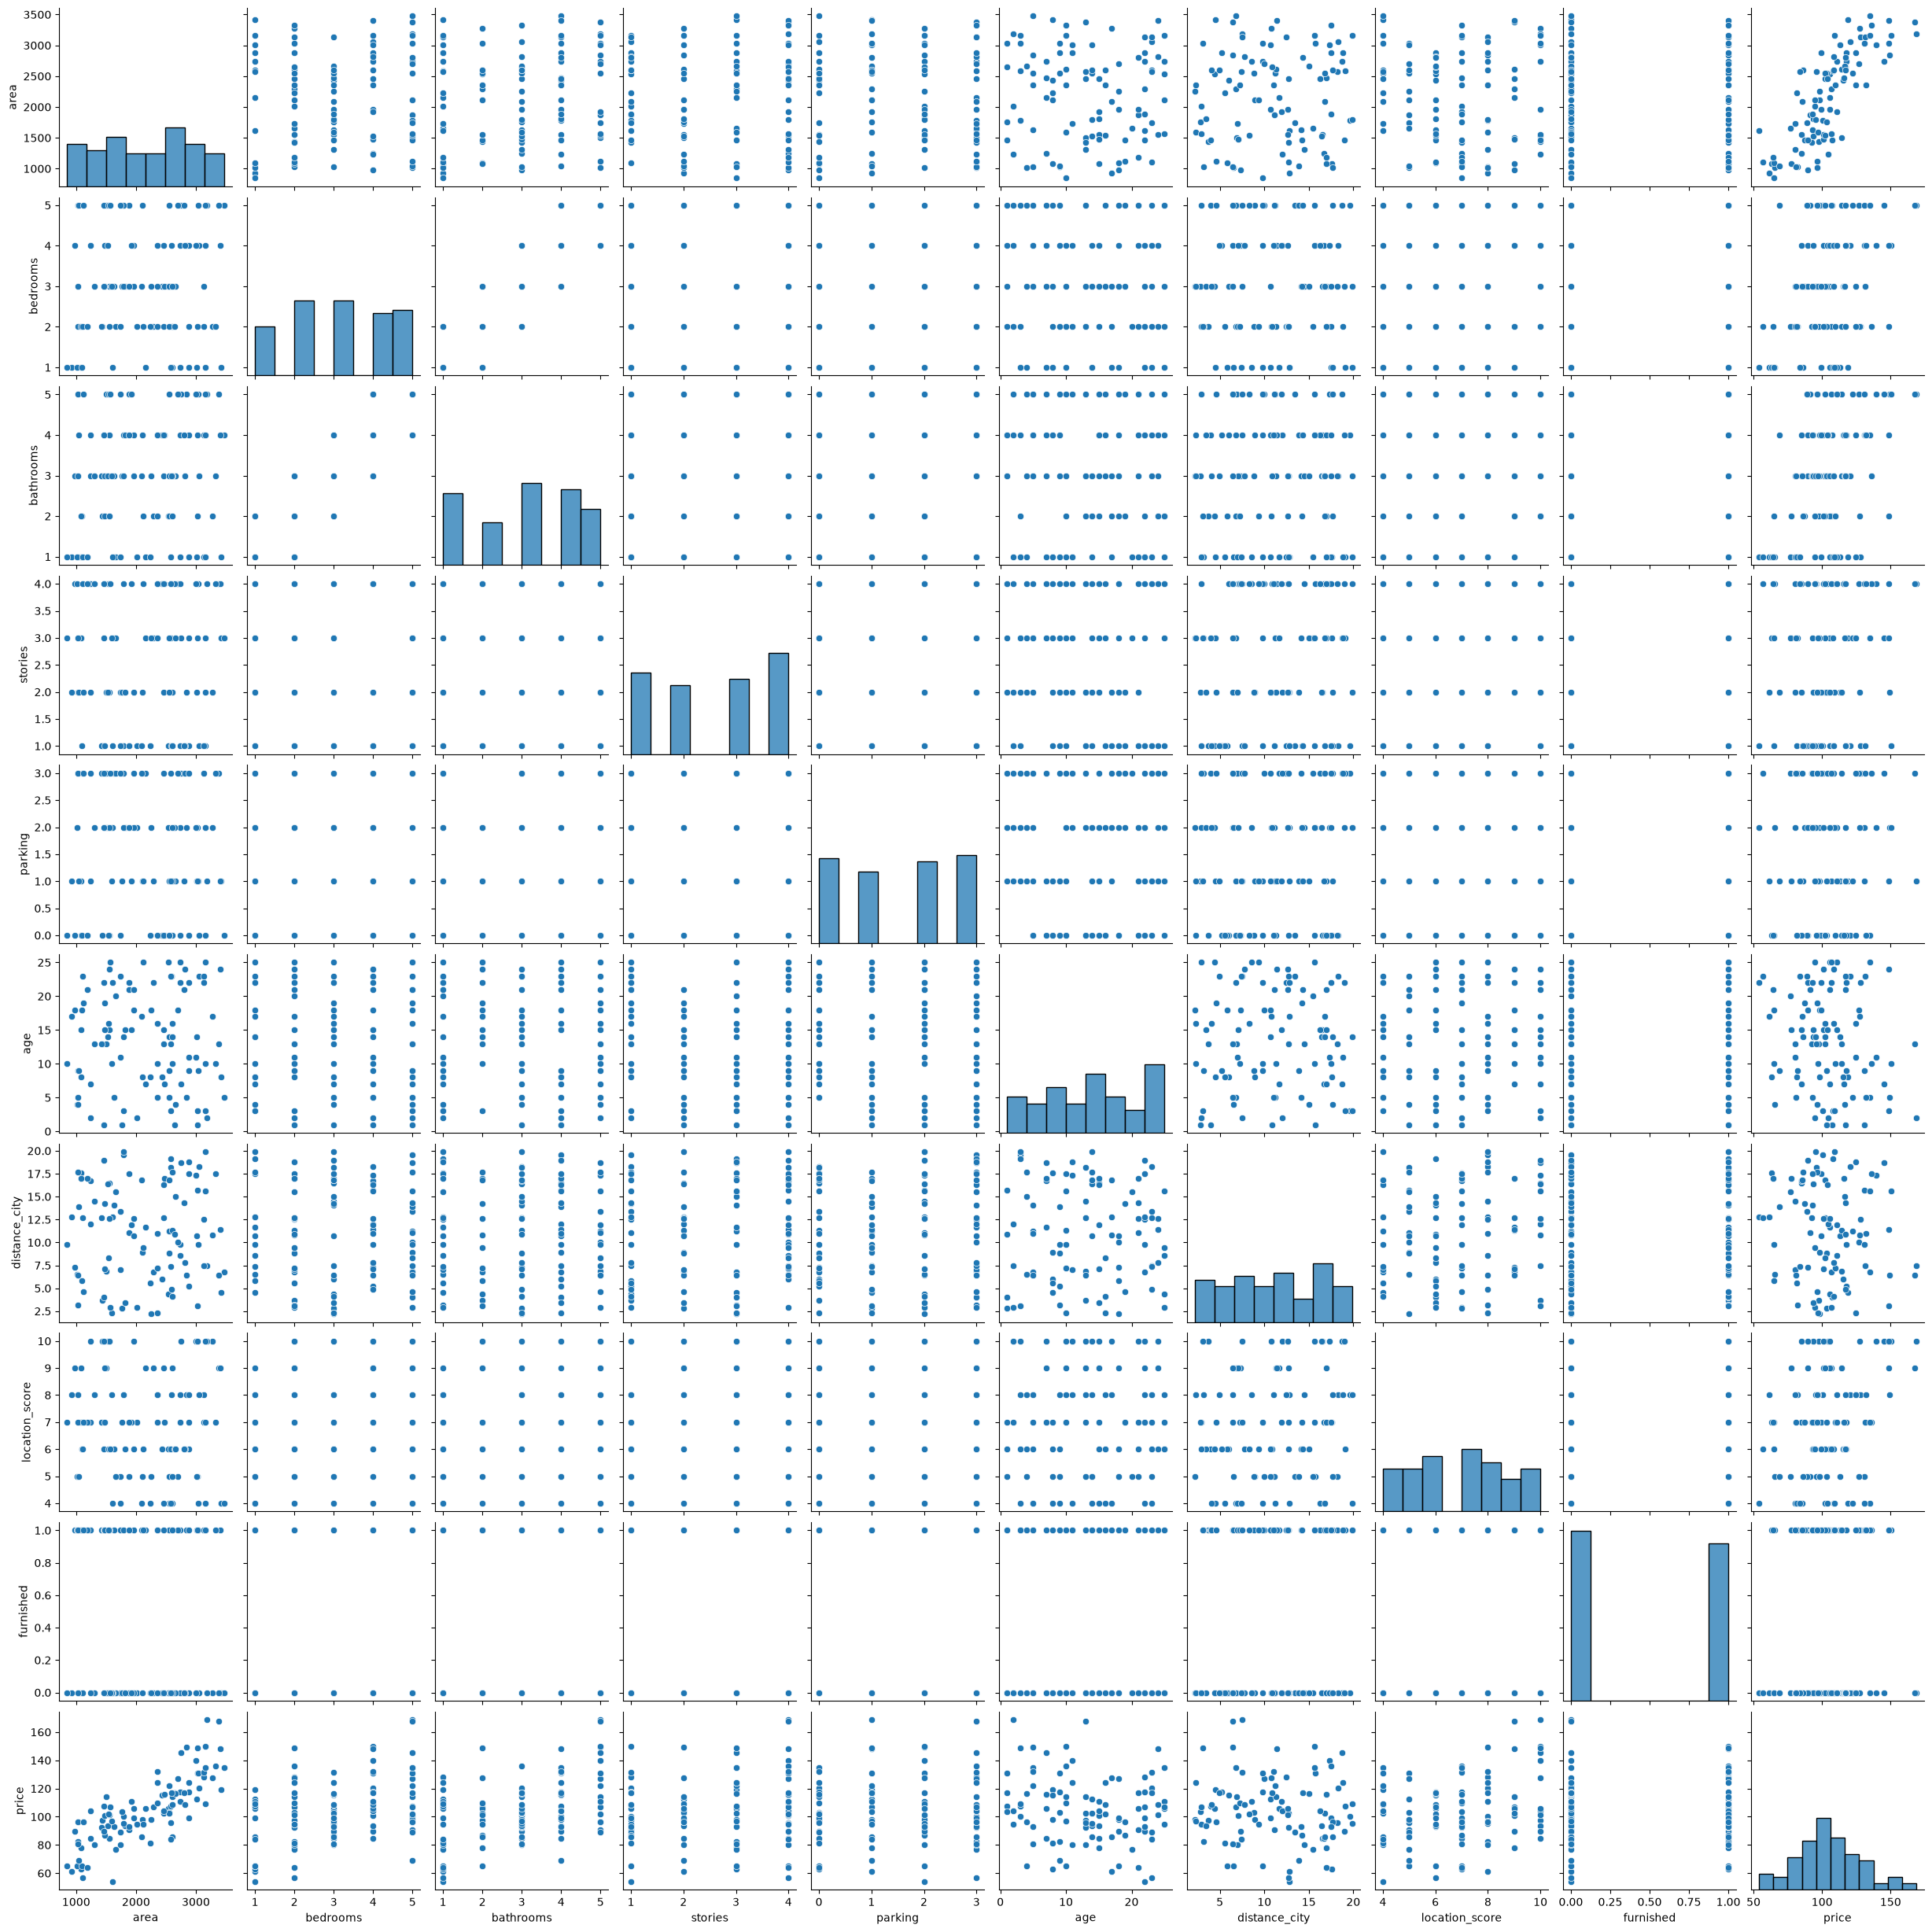

In [9]:
  sns.pairplot(data=df)

In [10]:
X=df.iloc[:,:5]
y=df.iloc[:,-1]

In [11]:
print(X.shape)
print(y.shape)

(100, 5)
(100,)


In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80, 5)
(20, 5)
(80,)
(20,)


In [17]:
model=LinearRegression()
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[0.02,2.76,4.34,2.35,1.88]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['area','bedrooms','bathrooms','stories','parking']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,22.21
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [19]:
y_pred=model.predict(X_test)
y_pred

array([104.22994266, 137.02436286,  87.05504474, 108.25128881,
       102.38492817,  84.08437029,  89.85823404, 131.15750191,
       128.07800762, 120.47915818, 101.96494766,  71.34932548,
       112.26165501, 106.24015307, 114.06897018,  79.17862657,
        85.12125726,  73.75341208,  56.73761031, 144.07970751])

In [24]:
score =model.score(X_test,y_pred)
print("Model Trained Score",score)

Model Trained Score 1.0


In [29]:
df.sample()

,area,bedrooms,bathrooms,stories,parking,age,distance_city,location_score,furnished,price
47,3379,5,5,4,3,13,6.4,9,0,167.8


In [31]:
are=float(input("Enter total area"))
loc=float(input("Enter location score"))
sto=float(input("Enter number of stories"))
dis=float(input("Enter distance from city"))
bed=float(input("Enter number of bedroom"))
user_data=[[are,loc,sto,dis,bed]]
prediction=model.predict(user_data)[0]
print("Model predicted price is",round(prediction,2))
print(f"Model giving price with {score*100}% of accurate score price {prediction}")

Enter total area 3230
Enter location score 7.8
Enter number of stories 3
Enter distance from city 4
Enter number of bedroom 4


Model predicted price is 151.4
Model giving price with 100.0% of accurate score price 151.3958826775035


/opt/homebrew/Cellar/jupyterlab/4.6.3/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
